In [1]:
from ultralytics import YOLO


In [4]:
model = YOLO("../app/model/best.pt")

In [11]:
img_path = "../samples/image.png"


In [14]:
results = model.predict(
    source = img_path,
    save = True, #save output image
    conf=0.25, # confidence threshold
    project = "/home/prakash/prakash/dental_project/backend",
    name = "predictions"
)


image 1/1 /home/prakash/prakash/dental_project/backend/notebook/../samples/image.png: 352x640 9 Crowns, 10 Fillings, 1 Missing teeth, 2 Periapical lesions, 3 Root Canal Treatments, 2 Bone Losss, 1450.6ms
Speed: 11.8ms preprocess, 1450.6ms inference, 39.2ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /home/prakash/prakash/dental_project/backend/predictions


(np.float64(-0.5), np.float64(514.5), np.float64(276.5), np.float64(-0.5))

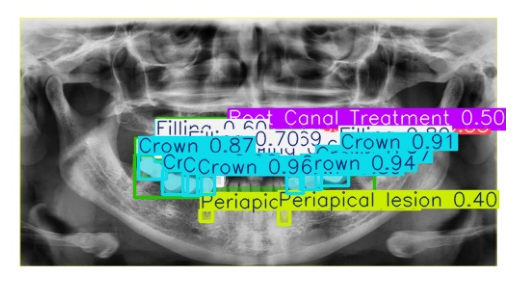

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

result_img = Image.open("../predictions/image.jpg")
plt.imshow(result_img)
plt.axis('off')

In [20]:
print(results)

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'Caries', 1: 'Crown', 2: 'Filling', 3: 'Implant', 4: 'Malaligned', 5: 'Mandibular Canal', 6: 'Missing teeth', 7: 'Periapical lesion', 8: 'Retained root', 9: 'Root Canal Treatment', 10: 'Root Piece', 11: 'impacted tooth', 12: 'maxillary sinus', 13: 'Bone Loss', 14: 'Fracture teeth', 15: 'Permanent Teeth', 16: 'Supra Eruption', 17: 'TAD', 18: 'abutment', 19: 'attrition', 20: 'bone defect', 21: 'gingival former', 22: 'metal band', 23: 'orthodontic brackets', 24: 'permanent retainer', 25: 'post - core', 26: 'plating', 27: 'wire', 28: 'Cyst', 29: 'Root resorption', 30: 'Primary teeth'}
obb: None
orig_img: array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 2

In [21]:
for r in results:
    print(r.boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  9.,  7.,  9., 13.,  6.,  2.,  9.,  7.,  1., 13.])
conf: tensor([0.9563, 0.9413, 0.9114, 0.9093, 0.8993, 0.8904, 0.8703, 0.8684, 0.7992, 0.7023, 0.6929, 0.6180, 0.6147, 0.6026, 0.5966, 0.5725, 0.5621, 0.5041, 0.3990, 0.3696, 0.3358, 0.3340, 0.3303, 0.2823, 0.2788, 0.2523, 0.2516])
data: tensor([[1.9489e+02, 1.7241e+02, 2.1244e+02, 1.9227e+02, 9.5632e-01, 1.0000e+00],
        [3.0196e+02, 1.6804e+02, 3.2374e+02, 1.8785e+02, 9.4131e-01, 1.0000e+00],
        [1.7959e+02, 1.7044e+02, 1.9848e+02, 1.9376e+02, 9.1139e-01, 1.0000e+00],
        [3.4397e+02, 1.4629e+02, 3.7585e+02, 1.6905e+02, 9.0928e-01, 1.0000e+00],
        [1.5825e+02, 1.6726e+02, 1.8464e+02, 1.9220e+02, 8.9932e-01, 1.0000e+00],
        [2.8716e+02, 1.7271e+02, 3.0401e+02, 1.9110e+02, 8.9035e-01, 1.0000e+00],
        [3.1708e+02, 1.5950e+02, 3.5103e+02, 1.8383e+02, 8.7029e

In [22]:
for r in results:
  boxes = r.boxes

  for i in range(len(boxes)):
    cls_id = int(boxes.cls[i])
    conf = float(boxes.conf[i])
    coords = boxes.xyxy[i].tolist()

    #Filter low confidence
    if conf > 0.5:
      print(f"Class: {cls_id}, Confidence: {conf:.2f}, Box: {coords}")

Class: 1, Confidence: 0.96, Box: [194.8944854736328, 172.4093475341797, 212.43569946289062, 192.2676544189453]
Class: 1, Confidence: 0.94, Box: [301.95928955078125, 168.0381622314453, 323.7441711425781, 187.8486785888672]
Class: 1, Confidence: 0.91, Box: [179.58853149414062, 170.44004821777344, 198.48301696777344, 193.7580108642578]
Class: 1, Confidence: 0.91, Box: [343.9711608886719, 146.28817749023438, 375.8456115722656, 169.05389404296875]
Class: 1, Confidence: 0.90, Box: [158.24554443359375, 167.26296997070312, 184.6383056640625, 192.20086669921875]
Class: 1, Confidence: 0.89, Box: [287.1637878417969, 172.70755004882812, 304.0075988769531, 191.0972137451172]
Class: 1, Confidence: 0.87, Box: [317.0843811035156, 159.50375366210938, 351.02557373046875, 183.83352661132812]
Class: 1, Confidence: 0.87, Box: [133.5939483642578, 150.08799743652344, 162.59071350097656, 176.9972381591797]
Class: 2, Confidence: 0.80, Box: [341.3212890625, 139.26783752441406, 362.0108337402344, 147.95623779296

In [24]:
class_names = model.names

for r in results:
    boxes = r.boxes

    for i in range(len(boxes)):
        cls_id = int(boxes.cls[i])
        conf = float(boxes.conf[i])

       
        print(f"{class_names[cls_id]} → {conf:.2f}")

Crown → 0.96
Crown → 0.94
Crown → 0.91
Crown → 0.91
Crown → 0.90
Crown → 0.89
Crown → 0.87
Crown → 0.87
Filling → 0.80
Filling → 0.70
Filling → 0.69
Filling → 0.62
Filling → 0.61
Filling → 0.60
Filling → 0.60
Filling → 0.57
Filling → 0.56
Root Canal Treatment → 0.50
Periapical lesion → 0.40
Root Canal Treatment → 0.37
Bone Loss → 0.34
Missing teeth → 0.33
Filling → 0.33
Root Canal Treatment → 0.28
Periapical lesion → 0.28
Crown → 0.25
Bone Loss → 0.25


In [25]:
# List the IDs of the anomalies you want to keep
target_classes = [1, 2, 9]

results = model.predict(
    source = img_path,
    save = True,
    conf = 0.25,
    classes = target_classes, # Only predicts and draws these IDs
    project = "/home/prakash/prakash/dental_project/backend",
    name = "filtered_predictions",
    exist_ok = True
)


image 1/1 /home/prakash/prakash/dental_project/backend/notebook/../samples/image.png: 352x640 9 Crowns, 10 Fillings, 3 Root Canal Treatments, 1597.0ms
Speed: 21.9ms preprocess, 1597.0ms inference, 38.1ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /home/prakash/prakash/dental_project/backend/filtered_predictions


In [26]:
results = model.predict(source=img_path, conf=0.25)

for r in results:
    # 1. List all detected anomalies
    detected_ids = r.boxes.cls.tolist()
    names = model.names
    print(f"Detected: {[names[int(i)] for i in detected_ids]}")

    # 2. Define your filter (e.g., only keep Periapical lesions and Root Canal)
    # IDs: 7 and 9 based on your YAML
    filter_ids = [1]
    
    # 3. Create a mask to filter the boxes
    mask = [True if int(cls) in filter_ids else False for cls in r.boxes.cls]
    
    # Apply filter to boxes and masks (if segmenting)
    r.boxes = r.boxes[mask]
    if r.masks is not None:
        r.masks = r.masks[mask]

    # 4. Save the filtered image
    r.save(filename="/home/prakash/prakash/dental_project/backend/filtered_output.png")


image 1/1 /home/prakash/prakash/dental_project/backend/notebook/../samples/image.png: 352x640 9 Crowns, 10 Fillings, 3 Root Canal Treatments, 1418.6ms
Speed: 6.0ms preprocess, 1418.6ms inference, 14.8ms postprocess per image at shape (1, 3, 352, 640)
Detected: ['Crown', 'Crown', 'Crown', 'Crown', 'Crown', 'Crown', 'Crown', 'Crown', 'Filling', 'Filling', 'Filling', 'Filling', 'Filling', 'Filling', 'Filling', 'Filling', 'Filling', 'Root Canal Treatment', 'Root Canal Treatment', 'Filling', 'Root Canal Treatment', 'Crown']
